# APLICAÇÃO DE TÉCNICAS DE CIÊNCIA DE DADOS E MACHINE LEARNING PARA ANÁLISE E PREDIÇÃO DE RISCOS EM PROJETOS  

*  **Disciplina:** Prática em Ciência de Dados e Machine Learning
*   **Aluna**: Giovana de Oliveira Winter Afonso
*  **Base de dados:** project_risk_raw_dataset.csv
*  **Objetivo:** Explorar, analisar e prever o nível de risco de projetos atráves da aplicação do algoritmo de Machine Learning Random Forest
*  **Variável-alvo:** Risk_Level (Low, Medium, High, Critical)

---
## Descrição do Dataset

In [2]:
# Importação das bibliotecas necessárias para a análise, visualização e manipulação dos dados, e ferramentas de Machine Learning.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [1]:
# Montagem do drive para o carregamento da base de dados
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Leitura do arquivo CSV
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/PCD/project_risk_raw_dataset.csv')

# Dimensões da base
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')
print()

# Exibição das 5 primeiras linhas da base
print('Primeiras 5 linhas:')
df.head()

Linhas: 4000
Colunas: 51

Primeiras 5 linhas:


,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High


In [6]:
# Estrutura da Base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 51 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Project_ID                       4000 non-null   object 
 1   Project_Type                     4000 non-null   object 
 2   Team_Size                        4000 non-null   int64  
 3   Project_Budget_USD               4000 non-null   float64
 4   Estimated_Timeline_Months        4000 non-null   int64  
 5   Complexity_Score                 4000 non-null   float64
 6   Stakeholder_Count                4000 non-null   int64  
 7   Methodology_Used                 4000 non-null   object 
 8   Team_Experience_Level            4000 non-null   object 
 9   Past_Similar_Projects            4000 non-null   int64  
 10  External_Dependencies_Count      4000 non-null   int64  
 11  Change_Request_Frequency         4000 non-null   float64
 12  Project_Phase       

In [7]:
# Descrição das Variáveis
df.columns

Index(['Project_ID', 'Project_Type', 'Team_Size', 'Project_Budget_USD',
       'Estimated_Timeline_Months', 'Complexity_Score', 'Stakeholder_Count',
       'Methodology_Used', 'Team_Experience_Level', 'Past_Similar_Projects',
       'External_Dependencies_Count', 'Change_Request_Frequency',
       'Project_Phase', 'Requirement_Stability', 'Team_Turnover_Rate',
       'Vendor_Reliability_Score', 'Historical_Risk_Incidents',
       'Communication_Frequency', 'Regulatory_Compliance_Level',
       'Technology_Familiarity', 'Geographical_Distribution',
       'Stakeholder_Engagement_Level', 'Schedule_Pressure',
       'Budget_Utilization_Rate', 'Executive_Sponsorship', 'Funding_Source',
       'Market_Volatility', 'Integration_Complexity', 'Resource_Availability',
       'Priority_Level', 'Organizational_Change_Frequency',
       'Cross_Functional_Dependencies', 'Previous_Delivery_Success_Rate',
       'Technical_Debt_Level', 'Project_Manager_Experience',
       'Org_Process_Maturity', 'Dat

In [8]:
# Estatísticas básicas das colunas numéricas
df.describe().round(2)

,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Past_Similar_Projects,External_Dependencies_Count,Change_Request_Frequency,Team_Turnover_Rate,Vendor_Reliability_Score,...,Market_Volatility,Integration_Complexity,Resource_Availability,Organizational_Change_Frequency,Cross_Functional_Dependencies,Previous_Delivery_Success_Rate,Technical_Debt_Level,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,...,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,15.39,1143031.50,17.15,6.19,11.13,1.97,3.13,1.64,0.29,0.71,...,0.50,5.57,0.65,1.21,3.55,0.75,0.18,6.49,4.07,1.01
std,9.22,590878.12,6.93,2.21,4.43,1.75,1.61,1.17,0.17,0.16,...,0.29,2.61,0.20,0.97,2.32,0.14,0.30,3.48,2.88,0.03
min,2.00,159355.55,2.00,1.62,2.00,0.00,0.00,0.01,0.00,0.09,...,0.00,1.00,0.30,0.00,0.00,0.15,0.00,1.00,1.00,1.00
25%,9.00,692532.92,12.00,4.46,8.00,1.00,2.00,0.76,0.16,0.60,...,0.25,3.32,0.48,0.50,2.00,0.66,0.00,4.00,2.00,1.00
50%,13.00,1007471.80,17.00,6.02,10.00,2.00,3.00,1.37,0.27,0.73,...,0.50,5.60,0.65,0.96,4.00,0.77,0.00,7.00,3.00,1.00
75%,20.00,1475870.20,22.00,7.86,14.00,3.00,4.00,2.23,0.40,0.84,...,0.74,7.86,0.82,1.66,6.00,0.86,0.28,10.00,6.00,1.00
max,50.00,3768354.37,36.00,10.00,29.00,10.00,7.00,8.84,0.85,1.00,...,1.00,10.00,1.00,8.23,7.00,0.99,1.00,12.00,17.00,1.10


In [9]:
# Análise dos dados ausentes
valores_faltando = df.isnull().sum()
print('Valores faltantes por coluna:')
print(valores_faltando[valores_faltando > 0])

Valores faltantes por coluna:
Tech_Environment_Stability    2619
Change_Control_Maturity        780
Risk_Management_Maturity       791
dtype: int64


In [10]:
# Remoção das colunas com mais de 40% de valores nulos
df = df.dropna(thresh=int(len(df) * 0.6), axis=1)

# Remoção das linhas com valores nulos
df = df.dropna()

# Verificação e remoção de duplicatas
print('Duplicatas encontradas:', df.duplicated().sum())
df = df.drop_duplicates()

print(f'\nTamanho final da base: {df.shape[0]} linhas × {df.shape[1]} colunas')

Duplicatas encontradas: 0

Tamanho final da base: 2701 linhas × 50 colunas


---
## Análise de Dados

In [12]:
# Distribuição da variável-alvo Risk Level
ordem = ['Low', 'Medium', 'High', 'Critical']

# Contagem e proporção por nível de risco
contagem = df['Risk_Level'].value_counts().reindex(ordem)
proporcao = (contagem / len(df) * 100).round(1)

resumo_alvo = pd.DataFrame({'Quantidade': contagem, 'Proporção (%)': proporcao})
print('Distribuição da variável-alvo:')
print(resumo_alvo)

Distribuição da variável-alvo:
            Quantidade  Proporção (%)
Risk_Level                           
Low                697           25.8
Medium            1007           37.3
High               642           23.8
Critical           355           13.1


/tmp/ipykernel_877/2139557072.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk_Level', data=df, order=ordem, palette='Blues_d')


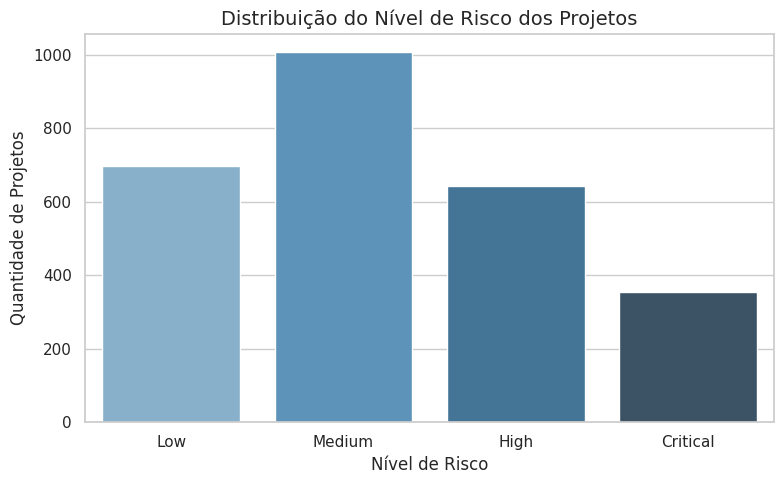

In [13]:
# Distribuição do nível de risco dos projetos

plt.figure(figsize=(8, 5))
sns.countplot(x='Risk_Level', data=df, order=ordem, palette='Blues_d')
plt.title('Distribuição do Nível de Risco dos Projetos', fontsize=14)
plt.xlabel('Nível de Risco')
plt.ylabel('Quantidade de Projetos')
plt.tight_layout()
plt.show()

In [14]:
# Estatísticas descritivas das variáveis numéricas
variaveis_numericas = [
    'Complexity_Score',
    'Team_Turnover_Rate',
    'Integration_Complexity',
    'Market_Volatility',
    'Change_Request_Frequency',
    'Budget_Utilization_Rate'
]

df[variaveis_numericas].describe().round(2)

,Complexity_Score,Team_Turnover_Rate,Integration_Complexity,Market_Volatility,Change_Request_Frequency,Budget_Utilization_Rate
count,2701.00,2701.00,2701.00,2701.00,2701.00,2701.00
mean,6.18,0.29,5.57,0.49,1.63,0.95
std,2.19,0.17,2.61,0.29,1.17,0.20
min,1.62,0.00,1.00,0.00,0.02,0.60
25%,4.49,0.16,3.31,0.24,0.76,0.77
50%,6.01,0.26,5.63,0.49,1.37,0.95
75%,7.80,0.40,7.86,0.74,2.20,1.12
max,10.00,0.85,9.98,1.00,8.84,1.30


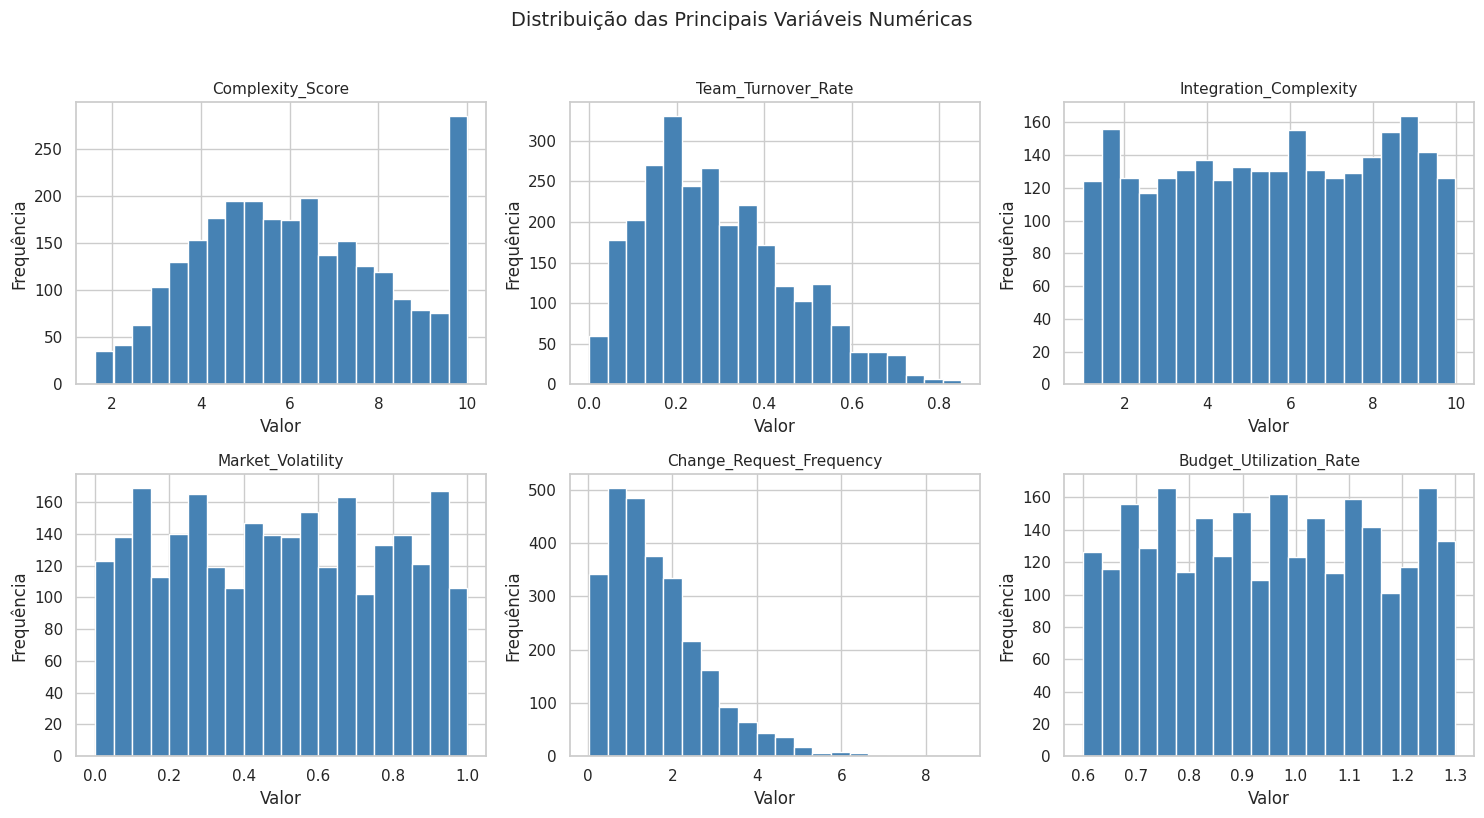

In [15]:
# Distribuição das variáveis numéicas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, coluna in enumerate(variaveis_numericas):
    df[coluna].hist(ax=axes[i], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(coluna, fontsize=11)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')

plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Perfil das variáveis categórias
categoricas = ['Project_Type', 'Methodology_Used', 'Project_Phase']

for col in categoricas:
    print(f'{col}')
    contagem_col = df[col].value_counts()
    proporcao_col = (contagem_col / len(df) * 100).round(1)
    tabela = pd.DataFrame({'Quantidade': contagem_col, 'Proporção (%)': proporcao_col})
    print(tabela)
    print()

Project_Type
               Quantidade  Proporção (%)
Project_Type                            
IT                   1001           37.1
Construction          510           18.9
R&D                   378           14.0
Healthcare            275           10.2
Marketing             275           10.2
Manufacturing         262            9.7

Methodology_Used
                  Quantidade  Proporção (%)
Methodology_Used                           
Agile                    764           28.3
Scrum                    702           26.0
Waterfall                514           19.0
Kanban                   400           14.8
Hybrid                   321           11.9

Project_Phase
               Quantidade  Proporção (%)
Project_Phase                           
Initiation            581           21.5
Planning              562           20.8
Execution             536           19.8
Closure               517           19.1
Monitoring            505           18.7



In [18]:
# Risco por tipo de projeto
tabela_cruzada = pd.crosstab(
    df['Project_Type'],
    df['Risk_Level'],
    normalize='index'
).round(3) * 100

tabela_cruzada = tabela_cruzada.reindex(columns=ordem, fill_value=0)

print('Proporção (%) de cada nível de risco por tipo de projeto:')
print(tabela_cruzada)

Proporção (%) de cada nível de risco por tipo de projeto:
Risk_Level      Low  Medium  High  Critical
Project_Type                               
Construction   28.0    35.1  24.1      12.7
Healthcare     33.1    39.3  21.5       6.2
IT             26.6    39.5  20.4      13.6
Manufacturing  34.7    38.9  20.2       6.1
Marketing      26.2    38.5  26.9       8.4
R&D             9.0    31.0  34.1      25.9


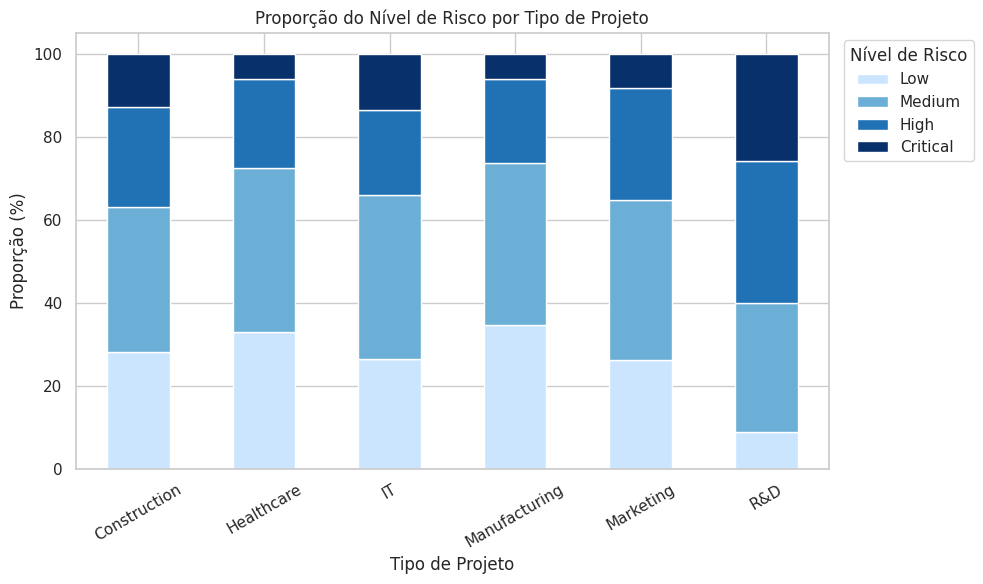

In [19]:
# Visualização: risco por tipo de projeto
tabela = (
    df.groupby(['Project_Type', 'Risk_Level'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ordem)
)
tabela_pct = tabela.div(tabela.sum(axis=1), axis=0) * 100

tabela_pct.plot(
    kind='bar',
    stacked=True,
    color=['#cce5ff', '#6baed6', '#2171b5', '#08306b'],
    figsize=(10, 6),
    edgecolor='white'
)
plt.title('Proporção do Nível de Risco por Tipo de Projeto')
plt.xlabel('Tipo de Projeto')
plt.ylabel('Proporção (%)')
plt.xticks(rotation=30)
plt.legend(title='Nível de Risco', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [20]:
# Média das variáveis por nível de risco
medias_por_risco = df.groupby('Risk_Level')[variaveis_numericas].mean().reindex(ordem).round(2)

print('Média de cada variável por nível de risco:')
print(medias_por_risco)

Média de cada variável por nível de risco:
            Complexity_Score  Team_Turnover_Rate  Integration_Complexity  \
Risk_Level                                                                 
Low                     5.30                0.23                    5.22   
Medium                  5.95                0.29                    5.58   
High                    6.59                0.32                    5.66   
Critical                7.83                0.35                    6.08   

            Market_Volatility  Change_Request_Frequency  \
Risk_Level                                                
Low                      0.44                      1.64   
Medium                   0.49                      1.68   
High                     0.54                      1.57   
Critical                 0.53                      1.55   

            Budget_Utilization_Rate  
Risk_Level                           
Low                            0.93  
Medium                         

/tmp/ipykernel_877/3310565563.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Level', y='Complexity_Score', data=df, order=ordem, palette='Blues')


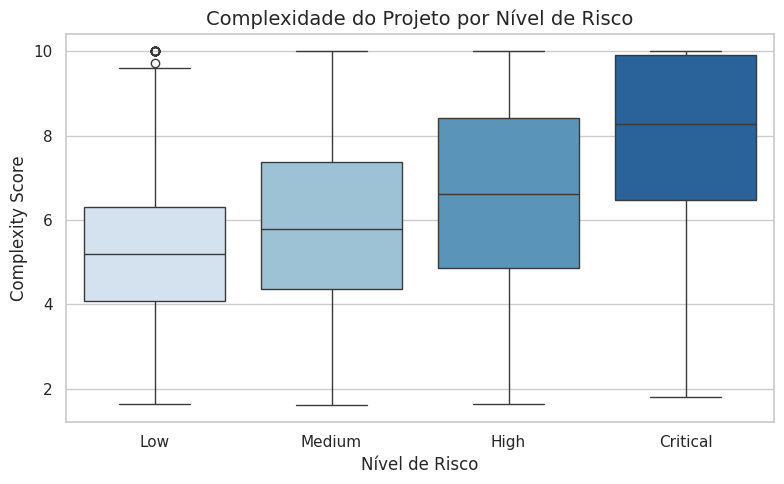

In [21]:
# Complexidade do projeto por Nível de Risco
plt.figure(figsize=(8, 5))
sns.boxplot(x='Risk_Level', y='Complexity_Score', data=df, order=ordem, palette='Blues')
plt.title('Complexidade do Projeto por Nível de Risco', fontsize=14)
plt.xlabel('Nível de Risco')
plt.ylabel('Complexity Score')
plt.tight_layout()
plt.show()

/tmp/ipykernel_877/2894887215.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Level', y='Team_Turnover_Rate', data=df, order=ordem, palette='Blues')


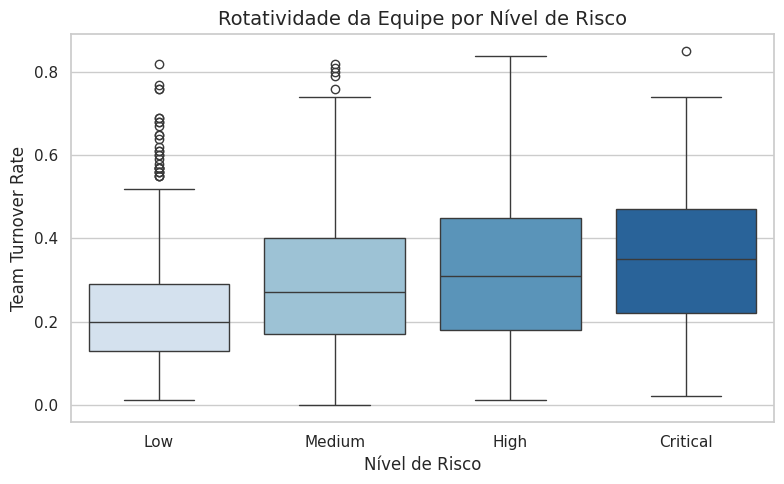

In [22]:
# Rotatividade da Equipe por Nível de Risco
plt.figure(figsize=(8, 5))
sns.boxplot(x='Risk_Level', y='Team_Turnover_Rate', data=df, order=ordem, palette='Blues')
plt.title('Rotatividade da Equipe por Nível de Risco', fontsize=14)
plt.xlabel('Nível de Risco')
plt.ylabel('Team Turnover Rate')
plt.tight_layout()
plt.show()

/tmp/ipykernel_877/4236986887.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Level', y='Team_Size', data=df, order=ordem, palette='Blues')


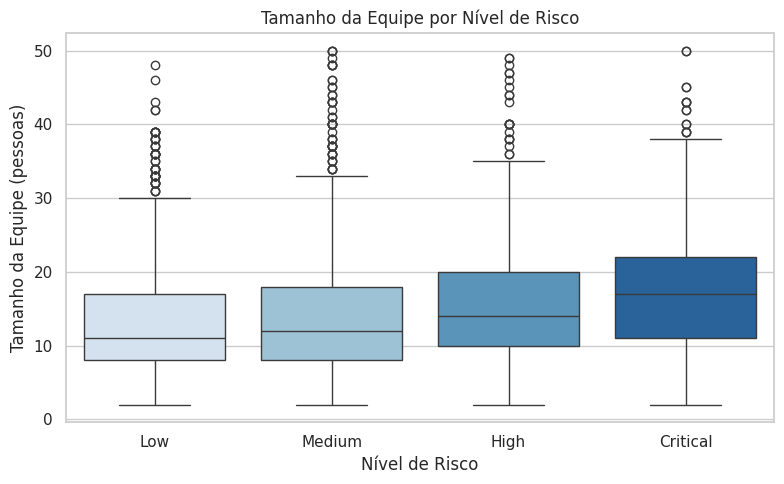

In [23]:
# Tamanho da Equipe por Nível de Risco
plt.figure(figsize=(8, 5))
sns.boxplot(x='Risk_Level', y='Team_Size', data=df, order=ordem, palette='Blues')
plt.title('Tamanho da Equipe por Nível de Risco')
plt.xlabel('Nível de Risco')
plt.ylabel('Tamanho da Equipe (pessoas)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_877/1586248874.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Level', y=col, data=df, order=ordem, palette='Blues', ax=axes[i])
/tmp/ipykernel_877/1586248874.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Level', y=col, data=df, order=ordem, palette='Blues', ax=axes[i])
/tmp/ipykernel_877/1586248874.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Level', y=col, data=df, order=ordem, palette='Blues', ax=axes[i])
/tmp/ipykernel_877/1586248874.py:6: FutureWarning: 

Passing `palette` without 

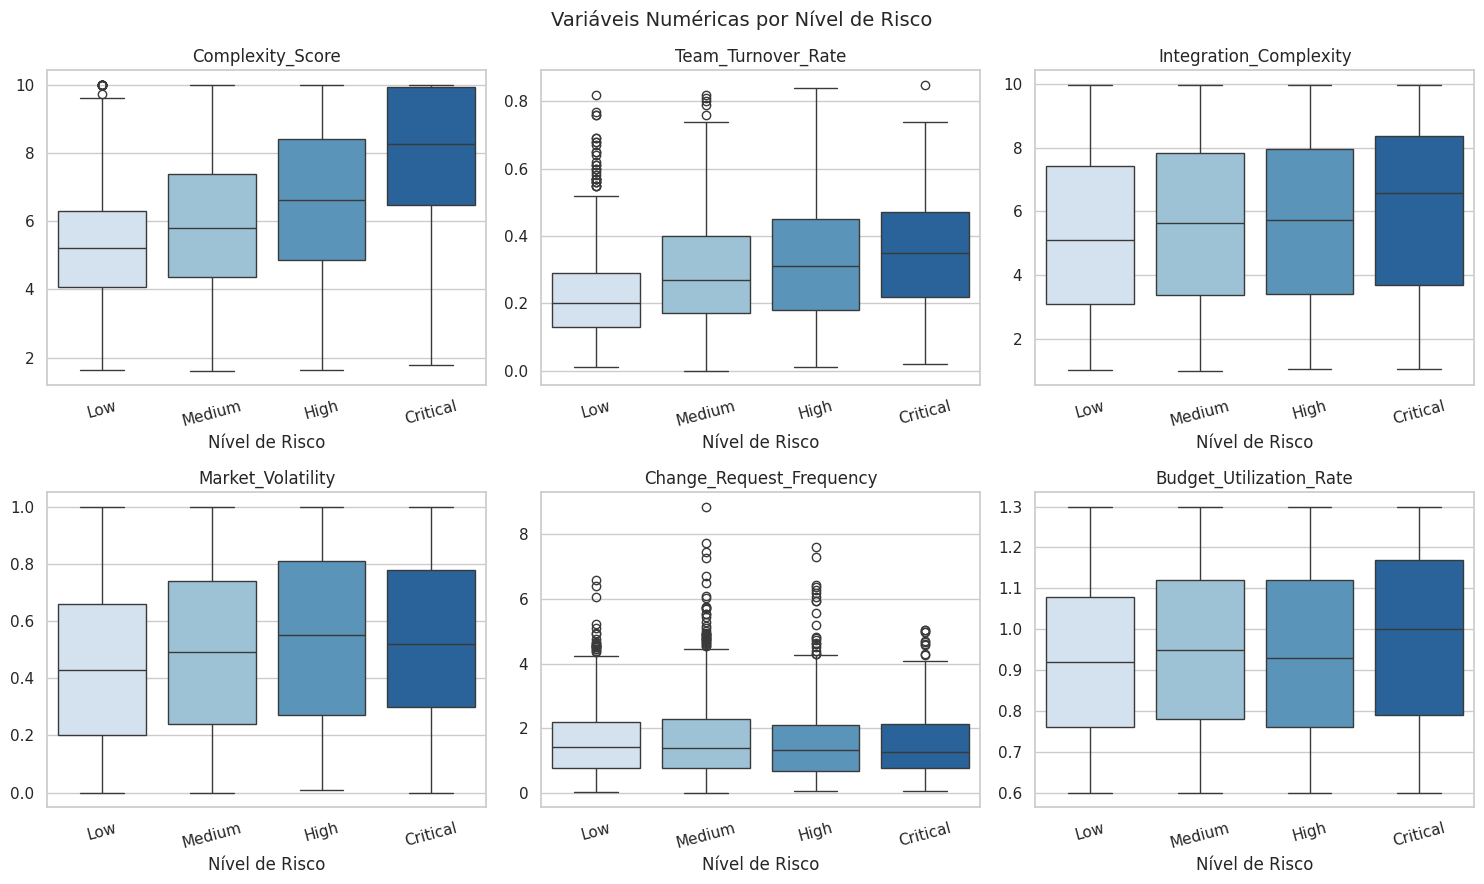

In [24]:
# Variáveis Numéricas por Nível de Risco
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(variaveis_numericas):
    sns.boxplot(x='Risk_Level', y=col, data=df, order=ordem, palette='Blues', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Nível de Risco')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Variáveis Numéricas por Nível de Risco', fontsize=14)
plt.tight_layout()
plt.show()

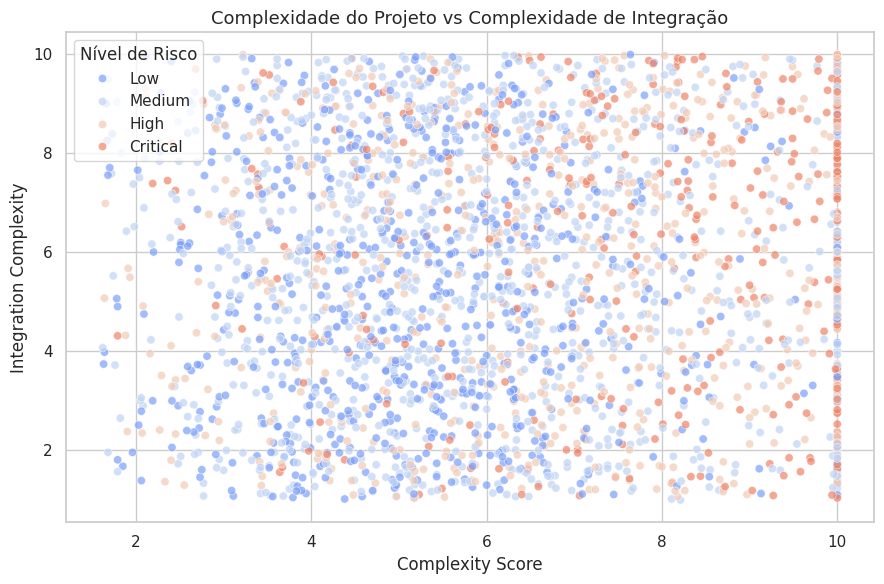

In [28]:
# Complexidade do Projeto vs Complexidade de Integração
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='Complexity_Score',
    y='Integration_Complexity',
    hue='Risk_Level',
    hue_order=ordem,
    data=df,
    alpha=0.7,
    palette='coolwarm'
)
plt.title('Complexidade do Projeto vs Complexidade de Integração', fontsize=13)
plt.xlabel('Complexity Score')
plt.ylabel('Integration Complexity')
plt.legend(title='Nível de Risco')
plt.tight_layout()
plt.show()

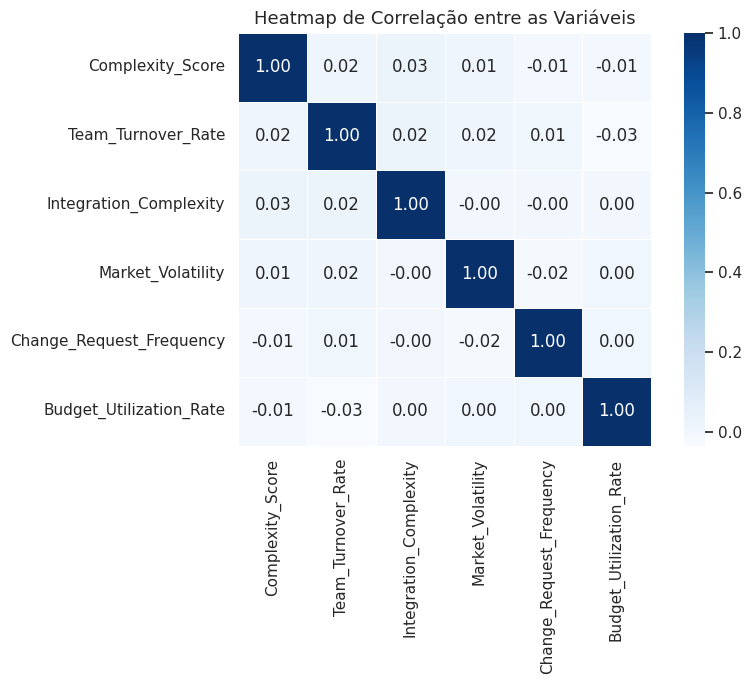

In [29]:
# Correlação entre as Principais Variáveis
correlacao = df[variaveis_numericas].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5, square=True)
plt.title('Heatmap de Correlação entre as Variáveis', fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# Caracteristicas que se destacam nos projetos críticos
criticos     = df[df['Risk_Level'] == 'Critical'][variaveis_numericas].mean().round(2)
nao_criticos = df[df['Risk_Level'] != 'Critical'][variaveis_numericas].mean().round(2)

comparacao = pd.DataFrame({
    'Média: Critical': criticos,
    'Média: Outros':   nao_criticos,
    'Diferença':        (criticos - nao_criticos).round(2)
})

print('Comparação entre projetos Critical e Outros:')
print(comparacao)

Comparação entre projetos Critical e Outros:
                          Média: Critical  Média: Outros  Diferença
Complexity_Score                     7.83           5.93       1.90
Team_Turnover_Rate                   0.35           0.28       0.07
Integration_Complexity               6.08           5.49       0.59
Market_Volatility                    0.53           0.49       0.04
Change_Request_Frequency             1.55           1.64      -0.09
Budget_Utilization_Rate              0.98           0.94       0.04


In [30]:
# Pares das variáveis mais correlacionadas
corr_pares = (
    correlacao
    .where(np.triu(np.ones(correlacao.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pares.columns = ['Variável A', 'Variável B', 'Correlação']
corr_pares = corr_pares.reindex(
    corr_pares['Correlação'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

print('Pares de variáveis ordenados por força de correlação:')
print(corr_pares.round(3))

Pares de variáveis ordenados por força de correlação:
                  Variável A                Variável B  Correlação
0         Team_Turnover_Rate   Budget_Utilization_Rate      -0.033
1           Complexity_Score    Integration_Complexity       0.029
2         Team_Turnover_Rate    Integration_Complexity       0.025
3           Complexity_Score        Team_Turnover_Rate       0.017
4         Team_Turnover_Rate         Market_Volatility       0.015
5          Market_Volatility  Change_Request_Frequency      -0.015
6           Complexity_Score         Market_Volatility       0.014
7         Team_Turnover_Rate  Change_Request_Frequency       0.009
8           Complexity_Score   Budget_Utilization_Rate      -0.008
9           Complexity_Score  Change_Request_Frequency      -0.007
10    Integration_Complexity  Change_Request_Frequency      -0.004
11  Change_Request_Frequency   Budget_Utilization_Rate       0.004
12         Market_Volatility   Budget_Utilization_Rate       0.004
13    In

In [33]:
# Resumo da Análise exploratória dos dados
print(f'Total de projetos na base (após limpeza): {len(df)}')
print(f'Total de variáveis disponíveis: {df.shape[1]}')
print()
print('Distribuição do nível de risco:')
for nivel in ordem:
    qtd = (df['Risk_Level'] == nivel).sum()
    pct = qtd / len(df) * 100
    print(f'  {nivel:<10}: {qtd} projetos ({pct:.1f}%)')
print()

dif = (criticos - nao_criticos).abs()
print('Variável com maior diferença nos projetos críticos:')
print(f' {dif.idxmax()} (diferença de {dif.max():.2f} pontos)')

Total de projetos na base (após limpeza): 2701
Total de variáveis disponíveis: 50

Distribuição do nível de risco:
  Low       : 697 projetos (25.8%)
  Medium    : 1007 projetos (37.3%)
  High      : 642 projetos (23.8%)
  Critical  : 355 projetos (13.1%)

Variável com maior diferença nos projetos críticos:
 Complexity_Score (diferença de 1.90 pontos)


---
## Machine Learning: Random Forest


In [35]:
# Pré-processamento
# Copia a base e remove o ID dos projetos
df_modelo = df.drop(columns=['Project_ID']).copy()

# Codifica todas as variáveis categóricas, exceto a variável-alvo (Risk_Level)
colunas_categoricas = df_modelo.select_dtypes(include='object').columns.tolist()
colunas_categoricas = [c for c in colunas_categoricas if c != 'Risk_Level']

for coluna in colunas_categoricas:
    le_col = LabelEncoder()
    df_modelo[coluna] = le_col.fit_transform(df_modelo[coluna])

# Codificador exclusivo para Risk_Level
le_alvo = LabelEncoder()
df_modelo['Risk_Level'] = le_alvo.fit_transform(df_modelo['Risk_Level'])

print('Mapeamento de classes (Risk_Level):')
for num, nome in enumerate(le_alvo.classes_):
    print(f'{num}: {nome}')

print(f'Total de variáveis utilizadas no modelo: {df_modelo.shape[1] - 1}')

Mapeamento de classes (Risk_Level):
0: Critical
1: High
2: Low
3: Medium
Total de variáveis utilizadas no modelo: 48


In [36]:
# Separação X Y e divisão de treino e teste
X = df_modelo.drop(columns=['Risk_Level'])
y = df_modelo['Risk_Level']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f'Total de variáveis explicativas: {X.shape[1]}')
print(f'Dados de treino: {len(X_treino)} exemplos')
print(f'Dados de teste:  {len(X_teste)} exemplos')

Total de variáveis explicativas: 48
Dados de treino: 1890 exemplos
Dados de teste:  811 exemplos


In [37]:
# Treinamento do modelo com hiperparâmetros ajustados
modelo = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_treino, y_treino)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [38]:
# Validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(modelo, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print('Acurácia por fold:')
for i, s in enumerate(scores, 1):
    print(f'  Fold {i}: {s:.2%}')

print()
print(f'Acurácia média:  {scores.mean():.2%}')
print(f'Desvio padrão:   {scores.std():.2%}')
print()

Acurácia por fold:
  Fold 1: 58.78%
  Fold 2: 55.37%
  Fold 3: 51.11%
  Fold 4: 55.93%
  Fold 5: 55.00%

Acurácia média:  55.24%
Desvio padrão:   2.45%



In [39]:
# Avaliação do modelo no conjunto de teste
y_previsto = modelo.predict(X_teste)

acuracia = accuracy_score(y_teste, y_previsto)
print(f'Acurácia no conjunto de teste: {acuracia:.2%}')
print()

print('Relatório de Classificação por Classe:')
print(classification_report(
    y_teste,
    y_previsto,
    target_names=le_alvo.classes_
))

Acurácia no conjunto de teste: 57.95%

Relatório de Classificação por Classe:
              precision    recall  f1-score   support

    Critical       0.58      0.40      0.48       107
        High       0.50      0.37      0.43       193
         Low       0.74      0.64      0.69       209
      Medium       0.53      0.74      0.62       302

    accuracy                           0.58       811
   macro avg       0.59      0.54      0.55       811
weighted avg       0.59      0.58      0.57       811



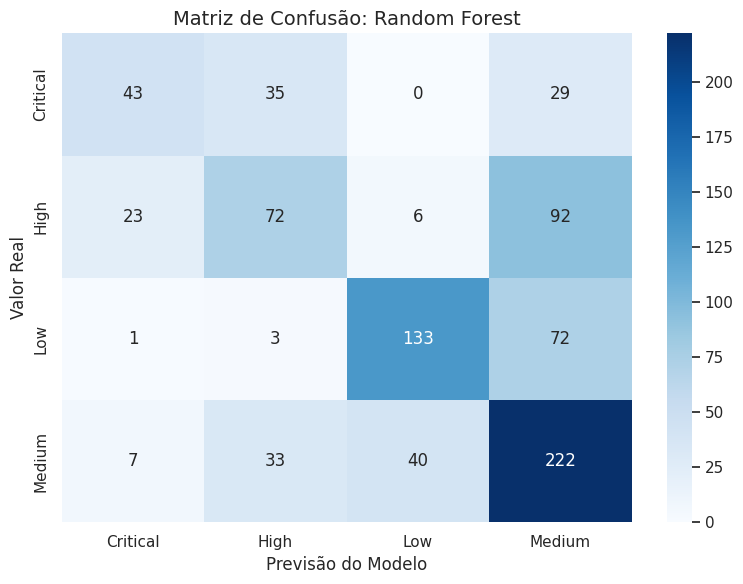

In [40]:
# Matriz de Confusão
cm = confusion_matrix(y_teste, y_previsto)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=le_alvo.classes_,
    yticklabels=le_alvo.classes_
)
plt.title('Matriz de Confusão: Random Forest', fontsize=14)
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

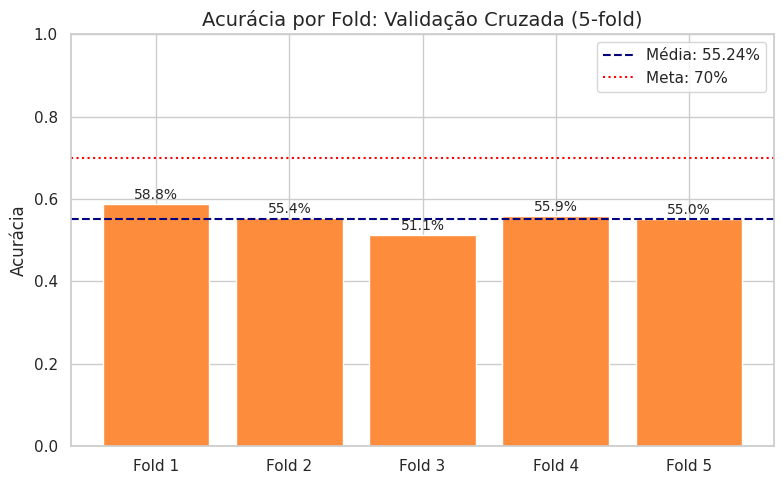

In [41]:
# Acurácia por Fold (validação cruzada)
plt.figure(figsize=(8, 5))
cores = ['#2171b5' if s >= 0.70 else '#fd8d3c' for s in scores]
bars = plt.bar([f'Fold {i}' for i in range(1, 6)], scores, color=cores, edgecolor='white')

plt.axhline(y=scores.mean(), color='navy', linestyle='--', linewidth=1.5,
            label=f'Média: {scores.mean():.2%}')
plt.axhline(y=0.70, color='red', linestyle=':', linewidth=1.5,
            label='Meta: 70%')

for bar, s in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{s:.1%}', ha='center', va='bottom', fontsize=10)

plt.title('Acurácia por Fold: Validação Cruzada (5-fold)', fontsize=14)
plt.ylabel('Acurácia')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

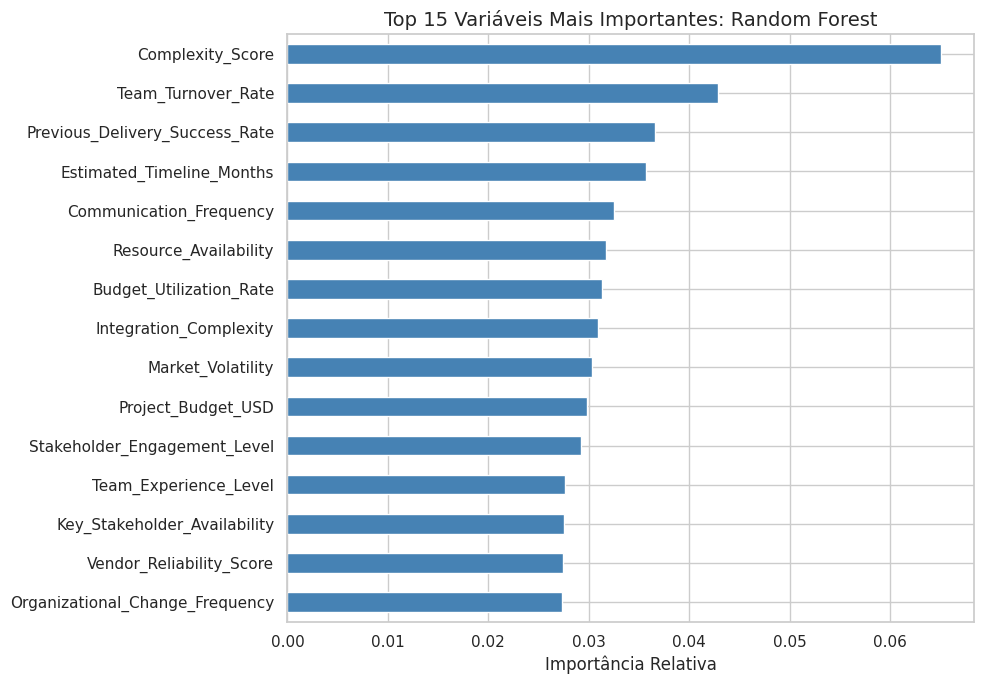

In [43]:
# Top 15 Variáveis Mais Importantes
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
top15 = importancias.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 7))
top15.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 15 Variáveis Mais Importantes: Random Forest', fontsize=14)
plt.xlabel('Importância Relativa')
plt.tight_layout()
plt.show()